# numpy vs python lists

In [ ]:
import numpy as np
# speed
a = [i for i in range(10000000)]
b = [i for i in range(10000000,20000000)]
c = []
import time
start = time.time()
for i in range(len(a)):
    c.append(a[i]+b[i])

print(time.time()-start)

# numpy 
a1 = np.arange(10000000)
b2 = np.arange(10000000,20000000)
start = time.time()
c = a+b
print(time.time()-start)


In [18]:
# memory
a = [i for i in range(10000000)]
import sys 
print(sys.getsizeof(a))

b = np.arange(10000000,dtype = np.int16)
print(sys.getsizeof(b))

89095160
20000112


In [ ]:
# convenience
# numpy provide better convenience than python list 

# advance indexing

In [23]:
 # fancy indexing
a2 = np.arange(12).reshape(4,3)

In [25]:
print(a2)

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


In [29]:
a2[[0,2,3]]

array([[ 0,  1,  2],
       [ 6,  7,  8],
       [ 9, 10, 11]])

In [35]:
a2[:,[0,1]]# for coulmn

array([[ 0,  1],
       [ 3,  4],
       [ 6,  7],
       [ 9, 10]])

In [53]:
# Boolean indexing
a3= np.random.randint(1,100,25).reshape(5,5)
a3

array([[32, 96, 77, 87,  7],
       [44, 61, 40, 70, 19],
       [64, 84, 72, 12, 66],
       [85, 90, 75, 23, 26],
       [98, 72, 90, 22, 78]])

In [61]:
a3>50

array([[False,  True,  True,  True, False],
       [False,  True, False,  True, False],
       [ True,  True,  True, False,  True],
       [ True,  True,  True, False, False],
       [ True,  True,  True, False,  True]])

In [65]:
a3[a3>50]

array([96, 77, 87, 61, 70, 64, 84, 72, 66, 85, 90, 75, 98, 72, 90, 78])

In [67]:
# find out even numbers
a3%2==0

array([[ True,  True, False, False, False],
       [ True, False,  True,  True, False],
       [ True,  True,  True,  True,  True],
       [False,  True, False, False,  True],
       [ True,  True,  True,  True,  True]])

In [69]:
a3[a3%2==0]

array([32, 96, 44, 40, 70, 64, 84, 72, 12, 66, 90, 26, 98, 72, 90, 22, 78])

In [75]:
# find all numbers greater than 50 and are even
a3[(a3>50)&(a3%2==0)]

array([96, 70, 64, 84, 72, 66, 90, 98, 72, 90, 78])

In [80]:
# find all numbers not divisible by 7
a3[~(a3%7==0)]

array([32, 96, 87, 44, 61, 40, 19, 64, 72, 12, 66, 85, 90, 75, 23, 26, 72,
       90, 22, 78])

# broadcasting

### Broadcasting

The term broadcasting describes how NumPy treats arrays with different shapes during arithmetic operations.

The smaller array is “broadcast” across the larger array so that they have compatible shapes.

In [83]:
# same shape
a = np.arange(6).reshape(2,3)
b = np.arange(6,12).reshape(2,3)

print(a)
print(b)

print(a+b)

[[0 1 2]
 [3 4 5]]
[[ 6  7  8]
 [ 9 10 11]]
[[ 6  8 10]
 [12 14 16]]


In [85]:
# diff shape
a = np.arange(6).reshape(2,3)
b = np.arange(3).reshape(1,3)

print(a)
print(b)

print(a+b)

[[0 1 2]
 [3 4 5]]
[[0 1 2]]
[[0 2 4]
 [3 5 7]]


#### Broadcasting Rules

**1. Make the two arrays have the same number of dimensions.**<br>
- If the numbers of dimensions of the two arrays are different, add new dimensions with size 1 to the head of the array with the smaller dimension.<br>

[link text](https://)**2. Make each dimension of the two arrays the same size.**<br>
- If the sizes of each dimension of the two arrays do not match, dimensions with size 1 are stretched to the size of the other array.
- If there is a dimension whose size is not 1 in either of the two arrays, it cannot be broadcasted, and an error is raised.

In [93]:
a = np.arange(12).reshape(4,3)
b = np.arange(3)
print(a)
print(b)
print(a+b)

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
[0 1 2]
[[ 0  2  4]
 [ 3  5  7]
 [ 6  8 10]
 [ 9 11 13]]


In [101]:
a = np.arange(12).reshape(3,4)
b = np.arange(3)
print(a)
print(b)
print(a+b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[0 1 2]


ValueError: operands could not be broadcast together with shapes (3,4) (3,) 

In [103]:
a = np.arange(3).reshape(1,3)
b = np.arange(3).reshape(3,1)

print(a)
print(b)

print(a+b)

[[0 1 2]]
[[0]
 [1]
 [2]]
[[0 1 2]
 [1 2 3]
 [2 3 4]]


In [105]:
a = np.arange(3).reshape(1,3)
b = np.arange(4).reshape(4,1)

print(a)
print(b)

print(a + b)

[[0 1 2]]
[[0]
 [1]
 [2]
 [3]]
[[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]]


In [109]:
a = np.array([1])
# shape -> (1,1)
b = np.arange(4).reshape(2,2)
# shape -> (2,2)

print(a)
print(b)
print(a+b)

[1]
[[0 1]
 [2 3]]
[[1 2]
 [3 4]]


In [111]:
a = np.arange(12).reshape(3,4)
b = np.arange(12).reshape(4,3)

print(a)
print(b)

print(a+b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


ValueError: operands could not be broadcast together with shapes (3,4) (4,3) 

In [113]:
a = np.arange(16).reshape(4,4)
b = np.arange(4).reshape(2,2)

print(a)
print(b)

print(a+b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
[[0 1]
 [2 3]]


ValueError: operands could not be broadcast together with shapes (4,4) (2,2) 

# working with mathematical formulas 


In [122]:
# sigmoid 
def sigmoid(array):
    return 1/(1+np.exp(-(array)))

In [124]:
a = np.arange(20)
sigmoid(a)

array([0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379,
       0.99330715, 0.99752738, 0.99908895, 0.99966465, 0.99987661,
       0.9999546 , 0.9999833 , 0.99999386, 0.99999774, 0.99999917,
       0.99999969, 0.99999989, 0.99999996, 0.99999998, 0.99999999])

In [126]:
# mean squared error
actual = np.random.randint(1,50,25)
predicted = np.random.randint(1,50,25)
def mse(actual,predicted):
    return np.mean((actual-predicted)**2)

mse(actual,predicted)

302.12

In [136]:
# binary cross entropy
def bce(actual,predicted):
    return -np.mean(actual*np.log(predicted)+(1-actual)*np.log(1-predicted))

In [138]:
bce(actual,predicted)

C:\Users\Aman Sahu\AppData\Local\Temp\ipykernel_18084\3924173393.py:3: RuntimeWarning: invalid value encountered in log
  return -np.mean(actual*np.log(predicted)+(1-actual)*np.log(1-predicted))


nan

# working with missing values 

In [147]:
a = np.array([1,2,3,4,5,6,7,8,np.nan,10])
np.isnan(a)

array([False, False, False, False, False, False, False, False,  True,
       False])

In [149]:
a[~np.isnan(a)] # it removed all nun values  

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8., 10.])

[-10.          -9.7979798   -9.5959596   -9.39393939  -9.19191919
  -8.98989899  -8.78787879  -8.58585859  -8.38383838  -8.18181818
  -7.97979798  -7.77777778  -7.57575758  -7.37373737  -7.17171717
  -6.96969697  -6.76767677  -6.56565657  -6.36363636  -6.16161616
  -5.95959596  -5.75757576  -5.55555556  -5.35353535  -5.15151515
  -4.94949495  -4.74747475  -4.54545455  -4.34343434  -4.14141414
  -3.93939394  -3.73737374  -3.53535354  -3.33333333  -3.13131313
  -2.92929293  -2.72727273  -2.52525253  -2.32323232  -2.12121212
  -1.91919192  -1.71717172  -1.51515152  -1.31313131  -1.11111111
  -0.90909091  -0.70707071  -0.50505051  -0.3030303   -0.1010101
   0.1010101    0.3030303    0.50505051   0.70707071   0.90909091
   1.11111111   1.31313131   1.51515152   1.71717172   1.91919192
   2.12121212   2.32323232   2.52525253   2.72727273   2.92929293
   3.13131313   3.33333333   3.53535354   3.73737374   3.93939394
   4.14141414   4.34343434   4.54545455   4.74747475   4.94949495
   5.151515

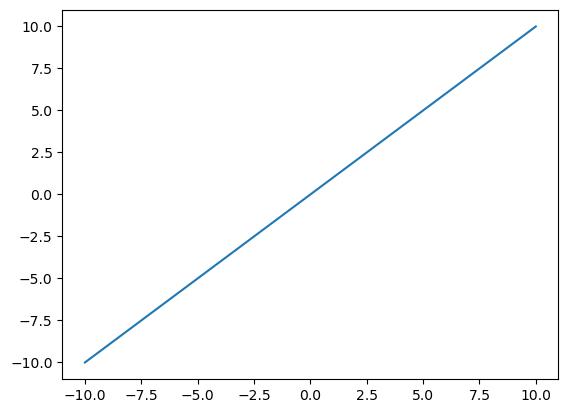

In [157]:
# plotting graphs 
import matplotlib.pyplot as plt
x = np.linspace(-10,10,100)
print(x)
y = x
print(y)
plt.plot(x,y)